# Figure 4 (SoRadIDX part): Hedged and Unhedged Buyer Cash Flows — 2022

Replicates the **left two panels** of Figure 4 from Romagnoli & Sartini (2025).

**Setup** (2022, calibration on 2005–2021):
- Buyer holds a solar farm: daily revenue $\text{CF}_u(R_n) = E_f \cdot N_p \cdot R_n \cdot \bar{E}$
- Benchmark (seasonal mean): $\text{CF}_b(K_n) = E_f \cdot N_p \cdot K_n \cdot \bar{E}$, where $K_n$ is the ATM daily strike
- Hedged: $\text{CF}_h = \text{CF}_u + N_c^* \cdot [\max(K_n - R_n, 0) \cdot \text{tick} - V_{0,n} \cdot \text{tick}]$
- $N_c^*$ minimises tracking error to the seasonal benchmark (closed-form quadratic solution)

**Coloring**: green when $R_n \geq K_n$ (above seasonal mean), red when $R_n < K_n$ (below).

Parameters: $E_f=0.15$, $N_p=10\,000$, $\bar{E}=0.08$, tick$=0.10$.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from solarrpy.calibration import calibrate_window
from solarrpy.sorad import sorad_price, daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, hedged_cf, optimal_Nc, mape, tick

## 0. Data and calibration (2013 window)

In [ ]:
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()  # H0 is computed internally, and the provided values are not trustworthy

# Bologna Coordinates used in the paper
LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

df_train = df[df['Year'] <= 2021].copy()
cal = calibrate_window(
    df_train,
    target_col='GHI', clearsky_col='clearsky', date_col='date',
    coords={'lat': LATITUDE}, train_end_year=2021,
)
print(f'theta={cal.theta:.4f}, alpha={cal.alpha:.4f}, beta={cal.beta:.4f}')

theta=0.8570, alpha=0.0001, beta=0.9129


In [ ]:
df_2022 = df[df['Year'] == 2022].sort_values('date').reset_index(drop=True)
print(f'Computing {len(df_2022)} daily SoRad prices for 2022...')
K_arr  = np.array([daily_strike(row['date'], cal) for _, row in df_2022.iterrows()])
R_arr  = df_2022['GHI'].values
cf_u = unhedged_cf(R_arr)                       # raw buyer revenue
cf_b = benchmark_cf(K_arr)                       # seasonal benchmark (black curve)
mape(cf_u, cf_b)

Computing 365 daily SoRad prices for 2014...


28.034707858721344

## 1. Compute per-day cash flows for 2022

In [5]:
# Conditioning: last observed day of 2021
t0_row = df[df['Year'] == 2021].sort_values('date').iloc[-1]
R_t0   = float(t0_row['GHI'])
t0     = t0_row['date']
print(f'Conditioning on t0={t0.date()}, R_t0={R_t0:.4f} kWh/m2')

# Per-day strikes, V0 prices, realized GHI
df_2022 = df[df['Year'] == 2022].sort_values('date').reset_index(drop=True)
print(f'Computing {len(df_2022)} daily SoRad prices for 2022...')

K_arr  = np.array([daily_strike(row['date'], cal) for _, row in df_2022.iterrows()])
V0_arr = np.array([
    sorad_price(K_arr[i], R_t0, str(t0.date()), str(row['date'].date()), cal)
    for i, (_, row) in enumerate(df_2022.iterrows())
])
R_arr  = df_2022['GHI'].values
days   = df_2022.index.values + 1   # day 1..365

print(f'Done. K range: {K_arr.min():.2f}-{K_arr.max():.2f} kWh/m2')
print(f'V0  range: {V0_arr.min():.3f}-{V0_arr.max():.3f} kWh/m2')

Conditioning on t0=2021-12-31, R_t0=1.8074 kWh/m2
Computing 365 daily SoRad prices for 2022...
Done. K range: 1.23-7.56 kWh/m2
V0  range: 0.164-1.184 kWh/m2


In [6]:
# Optimal hedge ratio
N_c = optimal_Nc(R_arr, K_arr, V0_arr)
print(f'Optimal N_c = {N_c:.1f} contracts')

# Cash flows
cf_u = unhedged_cf(R_arr)                       # raw buyer revenue
cf_b = benchmark_cf(K_arr)                       # seasonal benchmark (black curve)
cf_h = hedged_cf(R_arr, K_arr, V0_arr, N_c)     # hedged revenue

# Dense benchmark curve for smooth black line
dates_dense = pd.date_range('2022-01-01', '2022-12-31', freq='D')
K_dense     = np.array([daily_strike(d, cal) for d in dates_dense])
cfb_dense   = benchmark_cf(K_dense)
days_dense  = np.arange(1, len(dates_dense) + 1)

# Point colours: green if R_n >= K_n, red if R_n < K_n
above  = R_arr >= K_arr

print(f'Unhedged CF: {cf_u.min():.0f}-{cf_u.max():.0f} Eur')
print(f'Hedged   CF: {cf_h.min():.0f}-{cf_h.max():.0f} Eur')
print(f'Benchmark:   {cf_b.min():.0f}-{cf_b.max():.0f} Eur')
print(f'Green days (R>=K): {above.sum()}  |  Red days (R<K): {(~above).sum()}')
print(f'Unhedged MAPE: {mape(cf_u, cf_b):.2f}%')
print(f'Hedged   MAPE: {mape(cf_h, cf_b):.2f}%')

Optimal N_c = 1512.8 contracts
Unhedged CF: 42-1035 Eur
Hedged   CF: 115-945 Eur
Benchmark:   148-907 Eur
Green days (R>=K): 219  |  Red days (R<K): 146
Unhedged MAPE: 28.03%
Hedged   MAPE: 12.11%


## 2. Figure 4 (left two panels): SoRadIDX buyer cash flows

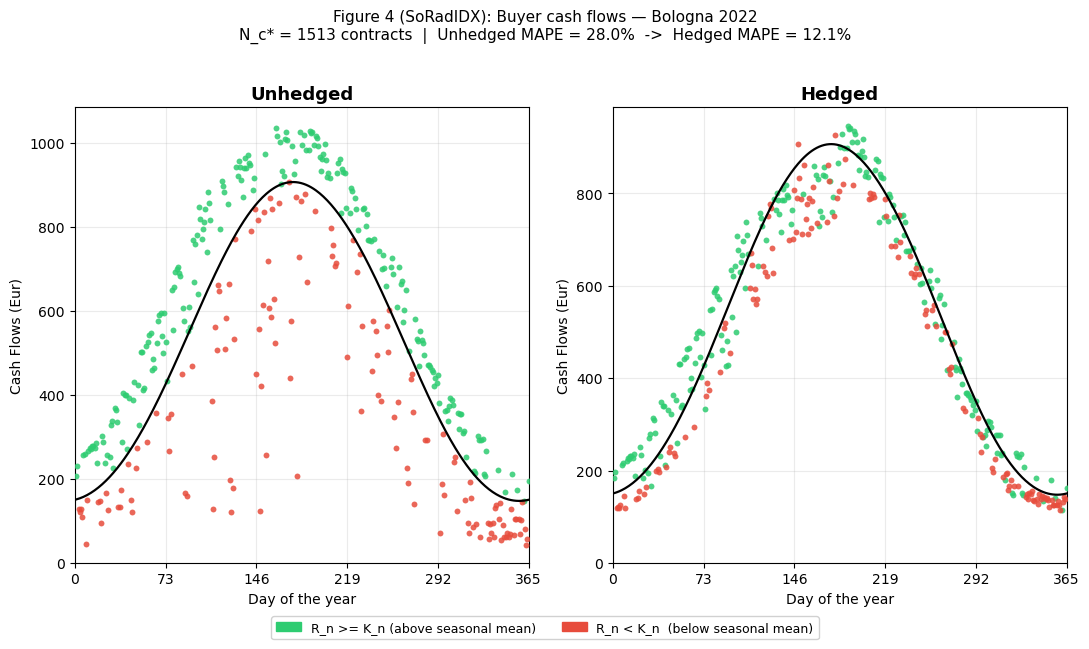

Saved Figure4_soradidx_buyer_cashflows.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=False)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='R_n >= K_n (above seasonal mean)'),
    mpatches.Patch(color='#e74c3c', label='R_n < K_n  (below seasonal mean)'),
]

for ax, cf_vals, title in [
    (axes[0], cf_u, 'Unhedged'),
    (axes[1], cf_h, 'Hedged'),
]:
    # Scatter: green above seasonal mean, red below
    ax.scatter(days[above],  cf_vals[above],  s=18, color='#2ecc71',
               alpha=0.85, zorder=3, linewidths=0)
    ax.scatter(days[~above], cf_vals[~above], s=18, color='#e74c3c',
               alpha=0.85, zorder=3, linewidths=0)

    # Smooth seasonal benchmark (black curve)
    ax.plot(days_dense, cfb_dense, color='black', lw=1.6, zorder=4)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Day of the year', fontsize=10)
    ax.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax.set_xlim(0, 365)
    ax.set_ylim(bottom=0)
    ax.set_xticks([0, 73, 146, 219, 292, 365])
    ax.grid(True, alpha=0.25)

fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Figure 4 (SoRadIDX): Buyer cash flows — Bologna 2022\n'
    f'N_c* = {N_c:.0f} contracts  |  '
    f'Unhedged MAPE = {mape(cf_u, cf_b):.1f}%  ->  '
    f'Hedged MAPE = {mape(cf_h, cf_b):.1f}%',
    fontsize=11, y=1.02,
)
fig.tight_layout()
plt.savefig('../results/Figure4_soradidx_buyer_cashflows.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure4_soradidx_buyer_cashflows.png')

In [ ]:
# weekly CF comparison 



# negative and positive CF

## 3. Gate checks

In [8]:
# Gate 1: all CF non-negative
assert cf_u.min() >= 0, f'Negative unhedged CF: {cf_u.min():.2f}'
assert cf_h.min() >= 0, f'Negative hedged CF: {cf_h.min():.2f}'
print('GATE PASS: All cash flows non-negative')

# Gate 2: hedge reduces MAPE
assert mape(cf_h, cf_b) < mape(cf_u, cf_b), 'Hedge did not reduce MAPE'
print(f'GATE PASS: Hedged MAPE ({mape(cf_h,cf_b):.2f}%) < Unhedged MAPE ({mape(cf_u,cf_b):.2f}%)')

# Gate 3: benchmark peaks in summer
peak_day = int(np.argmax(cfb_dense)) + 1
assert 150 <= peak_day <= 220, f'Benchmark peak at day {peak_day}'
print(f'GATE PASS: Benchmark peaks at day {peak_day} (summer solstice region)')

# Gate 4: hedge reduces variance relative to benchmark
var_u = np.var(cf_u - cf_b)
var_h = np.var(cf_h - cf_b)
assert var_h < var_u, 'Hedge did not reduce variance'
print(f'GATE PASS: Hedged variance ({var_h:.0f}) < Unhedged variance ({var_u:.0f})')

# Gate 5: red/green split is reasonable (not all one colour)
assert 100 <= above.sum() <= 265
print(f'GATE PASS: {above.sum()} green days, {(~above).sum()} red days')

print()
print('Figure 4 (SoRadIDX part) complete.')
print(f'  Saved: results/Figure4_soradidx_buyer_cashflows.png')

GATE PASS: All cash flows non-negative
GATE PASS: Hedged MAPE (12.20%) < Unhedged MAPE (29.66%)
GATE PASS: Benchmark peaks at day 176 (summer solstice region)
GATE PASS: Hedged variance (2900) < Unhedged variance (28698)
GATE PASS: 168 green days, 197 red days

Figure 4 (SoRadIDX part) complete.
  Saved: results/Figure4_soradidx_buyer_cashflows.png
